# Project 11: Visual Inspection of Connecting Rods

## A presentation of the overall project

This Jupyter Notebook file presents in a user friendly way the development (in its choices and final results) of *a software  system aimed at visual inspection of motorcycle connecting rods.* For a detailed description of the project specifications, refear to official assignment document [**"Visual Inspection of Connectiong Rods - Project Description"**](https://github.com/VincenzoLomba/ImageProcessingAndComputerVision/blob/master/pythonvenv/src/project/Visual%20Inspection%20of%20Connectiong%20Rods%20-%20Project%20Description.pdf).

As required by the specifications, the project is developed and presented as divided into two main parts: [**First Task**](#first-task) and [**Second Task**](#second-task).

In the case of the [**First Task**](#first-task), the software development is carried out relying in particular on the following simplifying assumptions:
- Images (to be visually inspected) contain **only** connecting-rods.
- These connecting-rods appear **well separated** in the images.
- Images have been acquired by the **backlighting technique** so to render rods easily distinguishable (i.e. much darker with respect to the background, supposed indeed to be much lighter).

That being said, the requirements are as follows:
- Work properly with lighting sources of different power (*without* requiring any manual parameters adjustment).
- For each connecting-rod, provide:<br>
**(a)** its type (A if with one hole, B if with two holes)<br>
**(b)** its position (alias baricenter) and orientation (modulo-pi)<br>
**(c)** its lenght, width and width-at-the-baricenter (respectively, L, W and Wc)<br>
**(d)** center position and diameter size of each one of its holes (one or two of them respectively for type A and B rods).

Later on, within the [**Second Task**](#second-task), a less simple scenario is considered and the previously presented software is upgraded accordingly. In particular, the following changes in the characteristics of the working images (which may also occur simultaneously) must be addressed:
1. Images may contain **other objects** (e.g. screws or washers) in addition to connecting-rods, alias **distractors** that need not to be analyzed by the software (but simply ignored).
2. Connecting-rods *(and only them)* may have contacts with each other (but without overlapping *and without touching distractors*).
3. The inspection area may be dirty due to the presence of scattered iron powder.

In [222]:
%matplotlib inline 

## First Task

### Images binarization through gray-level histogram thresholding

Working images are [considered to be] in grayscale. Furthermore, due to the fact that they are obtained through the backlighting technique, working images can be also considered to be **inherently binary** (alias with a bimodal gray-scale intensity distribution) and strongly prone to **binarization**. Being so, a straightforward and effective way to accomplish binarization of each image is by thresholding its gray-level histogram. To properly work with lighting sources of different power, the binarization threshold can be automatically computed relying on the **Otsu's Algorithm**.

In [223]:
import importlib, parameters, miscellaneous
importlib.reload(parameters)    # Be sure to load the latest version of our "parameters.py" module (useful in Jupyter Notebook)
importlib.reload(miscellaneous) # Be sure to load the latest version of our "miscellaneous.py" module (useful in Jupyter Notebook)
import cv2, numpy as np

imagesNames, images = miscellaneous.loadImages(miscellaneous.Task.FIRST_TASK)
binaryImages = []; histograms = []; otsuThresholds = []
for image in images:
    hist, _ = np.histogram(image.flatten(), bins = 256, range = [0,256])
    otsuThreshold, binaryImage = cv2.threshold(
        image,               # Input image (grayscale)
        0,                   # Threshold value (not used when using Otsu's method, so set to 0) 
        255,                 # Value to be assigned to pixels ABOVE the threshold
        cv2.THRESH_BINARY +  # First Flag, indicates binary thresholding (default Flag, specified here only for clarity)
        cv2.THRESH_OTSU      # Second flag, indicates relying on Otsu's algorithm (to determine the optimal threshold value)
    )                        # BKG will be associated to 255 (white), FRG/BLOB will be associated to 0 (black)
                             # (beacuse we're supposing that in the original image BKG is white-like and GRG/BLOBs are black-like)
    binaryImages.append(binaryImage)
    histograms.append(hist)
    otsuThresholds.append(otsuThreshold)

The obtained results confirm the capability to work with lighting sources of different power, as shown in the following example figures:

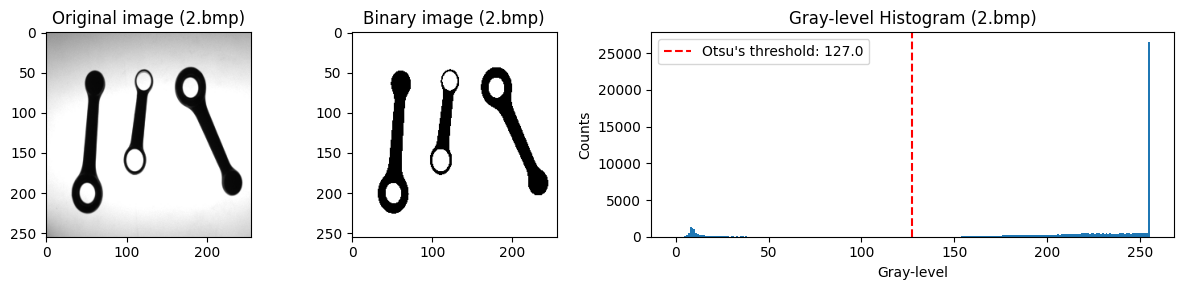

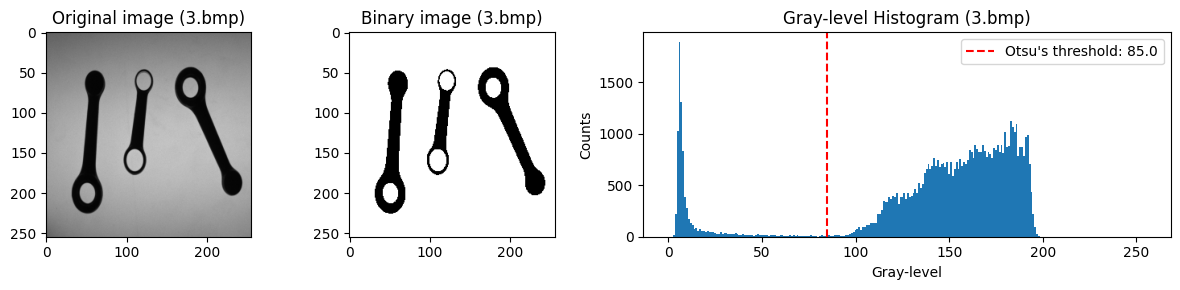

In [224]:
import plotter
importlib.reload(plotter) # Be sure to load the latest version of our "parameters.py" module (useful in Jupyter Notebook)
indices = [1, 2] # Indexes to be used only for visualization purposes within this Jupyter Notebook file
plotter.plotBinarizationResults(indices, imagesNames, images, binaryImages, histograms, otsuThresholds)


### Connected Components Labeling

Due to the simplifying assumptions of this [First Task](#first-task), we assume that in each obtained binary image **all** the connected components (alias BLOBs) correspond to distinct connecting-rods, without exceptions (all of that will be tackled in a more careful way in the [Second Task](#second-task)). That said, connected components (labelled and with [some statistics](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gac7099124c0390051c6970a987e7dc5c5)) can be obtained from the binary images thanks to the method [`cv2.connectedComponentsWithStats`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f). Some important keypoints:
- 8-connectivity will be adopted (to ensure a conservative definition of connected components *and thereby reducing the risk of artificial gaps in the end-rings*).
- `cv2.connectedComponentsWithStats` (as well as `cv2.findContours` and morphological operators implemented in OpenCV) assumes background pixels (BKG) to be coded as 0 and foreground pixels (FRG) to be coded as non-zero values. For this reason, a [`cv2.bitwise_not`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html?utm_source=chatgpt.com#ga0002cf8b418479f4cb49a75442baee2f) operation must be applied *before* processing the previously obtained binary images.

The following code extracts BLOBs from binary images. Furthermore, for each BLOB, its ROI is extracted from the original binary image. The ROI is defined as the BLOB’s axis-aligned Bounding Box. Also, within each ROI, all pixels that are ***not*** part of the related BLOB are set to 0 (alias set to BKG, accordingly to the previolsy stated convention of `cv2.connectedComponentsWithStats`):

In [225]:
from miscellaneous import RodBLOB
BLOBs = []
CONNECTIVITY = parameters.CONNECTIVITY
for index, binaryImage in enumerate(binaryImages):
    labels, labelledImage, stats, centroids = cv2.connectedComponentsWithStats(cv2.bitwise_not(binaryImage), connectivity = CONNECTIVITY)
    for label in range(1, labels): # Be aware: we are starting from 1 to skip the background label (labelled as 0)
        STAT_LEFT, STAT_TOP, STAT_WIDTH, STAT_HEIGHT, STAT_AREA = stats[label]
        ROI = labelledImage[STAT_TOP:STAT_TOP+STAT_HEIGHT, STAT_LEFT:STAT_LEFT+STAT_WIDTH].copy()
        ROI[ROI != label] = 0 # Getting rid of other BLOBs
        BLOB = RodBLOB(
            imageName = imagesNames[index],
            label = label,
            STAT_LEFT = STAT_LEFT,
            STAT_TOP = STAT_TOP,
            STAT_AREA = STAT_AREA,
            ROI = (ROI != 0).astype(np.uint8), # Setting 0 value for BKG pixels and 1 value for FRG/BLOB pixels
            centroid = centroids[label]
        )
        BLOBs.append(BLOB)

The obtained results are the various BLOBs extracted from the binary images (as expected), for example:

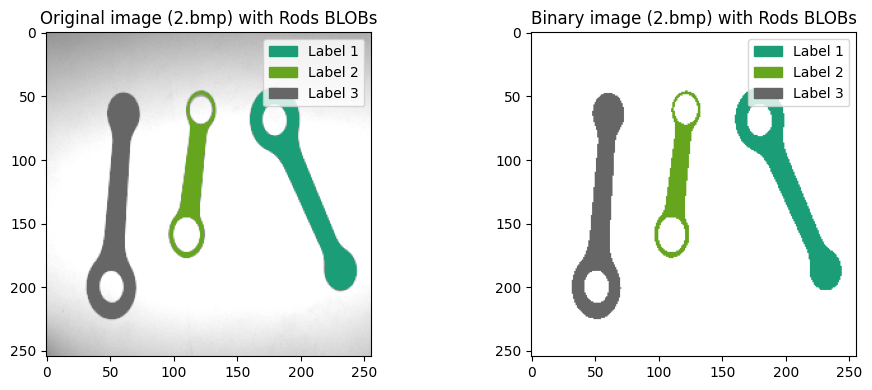

In [226]:
index = 1 # Index to be used only for visualization purposes within this Jupyter Notebook file
plotter.plotImageConnectedComponents(images[index], binaryImages[index], [b for b in BLOBs if b.imageName == imagesNames[index]])

Per oggi ci fermiamo qua, che ho sonno. prossimo step, fare vedere la rod rovianta e risolvere con erosione dei blob interni. poi, ottenuti i blob corretti, calcolare le rimanenti statistiche. poi si passa al task2.